# Production-Grade Ensemble CNN Classifier with Performance Benchmarks

**Dataset:** [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification) (real-world natural scene photographs, 6 classes) — used directly from the Kaggle Notebooks input mount, no download needed.

This notebook implements:
- 3 diverse CNNs (baseline, regularized, deep)
- Independent evaluation (accuracy, precision, recall, F1, confusion matrix)
- Ensemble via Majority Voting and Soft Voting
- Production benchmarking (latency, throughput, model size, parameter count, memory)
- Robustness testing (rotation, blur, noise, brightness)
- Model disagreement analysis
- Final production recommendation


In [4]:
import os, io, time, json, math, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Part 1 — Dataset: Load, Explore, Split, Normalize

In [5]:
TRAIN_DIR_GUESS = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
TEST_DIR_GUESS  = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"
PRED_DIR_GUESS  = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred"

def find_dir(candidates, target_name, search_root="/kaggle/input"):
    for c in candidates:
        if os.path.isdir(c):
            return c
    for dirpath, dirnames, _ in os.walk(search_root):
        if os.path.basename(dirpath) == target_name:
            return dirpath
    raise FileNotFoundError(f"Could not find a folder named '{target_name}' under {search_root}. "
                             f"Check the Input panel on the right for the exact attached path.")

TRAIN_DIR = find_dir([TRAIN_DIR_GUESS], "seg_train")
TEST_DIR  = find_dir([TEST_DIR_GUESS], "seg_test")
print("Train dir:", TRAIN_DIR)
print("Test dir :", TEST_DIR)


Train dir: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Test dir : /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test


In [6]:
# 85/15 split of seg_train for train/val, seg_test held out as the final test set —
# SAME split used for every CNN and the ensemble (fair comparison rule)
train_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.15, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=None, label_mode="int", shuffle=True,
)
val_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.15, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=None, label_mode="int", shuffle=True,
)
test_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=None, label_mode="int", shuffle=False,
)

CLASS_NAMES = train_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)
n_train = train_raw.cardinality().numpy()
n_val = val_raw.cardinality().numpy()
n_test = test_raw.cardinality().numpy()
print("Classes:", CLASS_NAMES)
print(f"Train: {n_train} | Val: {n_val} | Test: {n_test}")

Found 14034 files belonging to 6 classes.
Using 11929 files for training.
Found 14034 files belonging to 6 classes.
Using 2105 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 11929 | Val: 2105 | Test: 3000


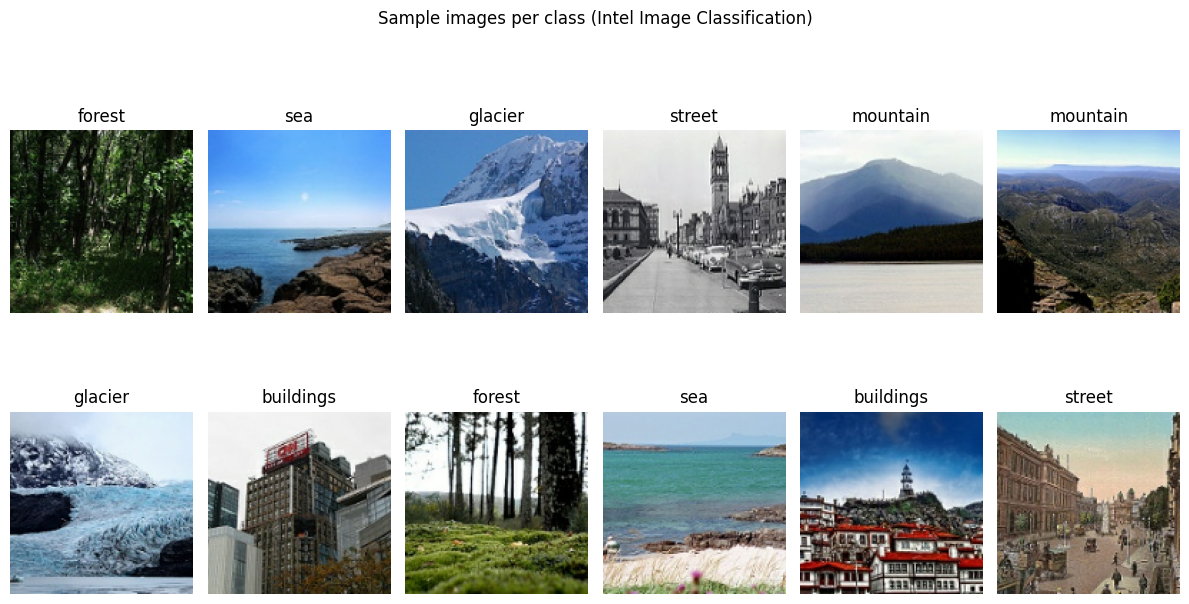

In [7]:
# Visualize a few sample images per class
plt.figure(figsize=(12, 7))
shown = {c: 0 for c in range(NUM_CLASSES)}
i = 0
for img, label in train_raw.take(600):
    lbl = int(label.numpy())
    if shown[lbl] < 2:
        i += 1
        plt.subplot(2, 6, i)
        plt.imshow(img.numpy().astype("uint8"))
        plt.title(CLASS_NAMES[lbl])
        plt.axis('off')
        shown[lbl] += 1
    if all(v >= 2 for v in shown.values()):
        break
plt.suptitle("Sample images per class (Intel Image Classification)")
plt.tight_layout()
plt.show()

In [8]:
# Resize + normalize (0-1). Augmentation is added separately and applied ONLY to the training pipeline.
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def make_pipeline(ds, training=False, augment_fn=None):
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if training and augment_fn is not None:
        ds = ds.map(lambda x, y: (augment_fn(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

## Part 2 — Data Augmentation (training data only)

Random horizontal flip, rotation, zoom, and brightness/contrast jitter. This teaches the CNNs to recognize flowers under different orientations and lighting — conditions they'll actually see in production — **without** ever touching the validation or test sets, so evaluation stays honest.

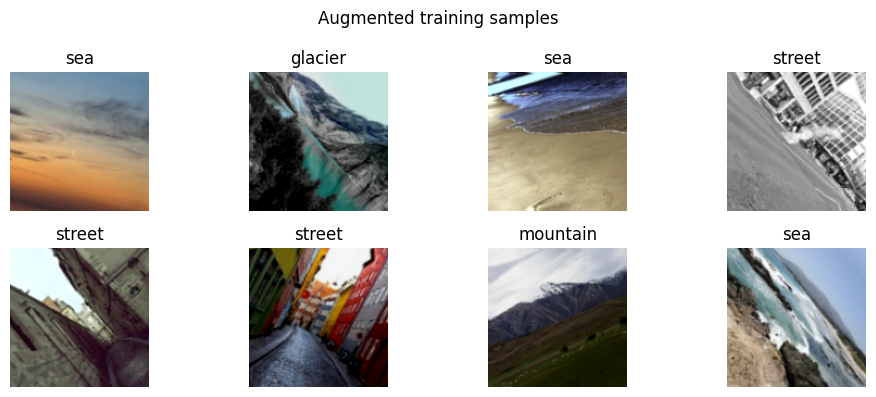

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15, value_range=(0, 1)),
], name="data_augmentation")

train_ds = make_pipeline(train_raw, training=True, augment_fn=data_augmentation)
val_ds   = make_pipeline(val_raw,   training=False)
test_ds  = make_pipeline(test_raw,  training=False)

# Peek at augmented images
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 4))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(CLASS_NAMES[int(tf.argmax(labels[i]))])
        plt.axis('off')
    plt.suptitle("Augmented training samples")
    plt.tight_layout()
    plt.show()

## Part 3 — CNN 1: Baseline CNN

Simple architecture: Conv → ReLU → Pool, twice, then Dense. This is the reference model everything else is measured against.

In [10]:
def build_cnn1_baseline(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ], name="CNN1_Baseline")
    return model

cnn1 = build_cnn1_baseline(IMG_SIZE + (3,), NUM_CLASSES)
cnn1.compile(optimizer=tf.keras.optimizers.Adam(0.001),
             loss='categorical_crossentropy', metrics=['accuracy'])
cnn1.summary()

Model: "CNN1_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,094 (28.20 MB)

 Trainable params: 7,393,094 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
os.makedirs("models", exist_ok=True)

def train_model(model, name, train_ds, val_ds, max_epochs=30):
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"models/{name}.keras", monitor='val_accuracy',
                                   save_best_only=True),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=max_epochs, callbacks=cb, verbose=1)
    return history

history_cnn1 = train_model(cnn1, "cnn_baseline", train_ds, val_ds)

Epoch 1/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 58s 133ms/step - accuracy: 0.5402 - loss: 1.1828 - val_accuracy: 0.6290 - val_loss: 1.0077
Epoch 2/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6670 - loss: 0.8939 - val_accuracy: 0.6812 - val_loss: 0.8631
Epoch 3/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7506 - loss: 0.6763 - val_accuracy: 0.6627 - val_loss: 0.9949
Epoch 4/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8461 - loss: 0.4407 - val_accuracy: 0.6618 - val_loss: 1.1919
Epoch 5/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9086 - loss: 0.2667 - val_accuracy: 0.6760 - val_loss: 1.4786
Epoch 6/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9449 - loss: 0.1694 - val_accuracy: 0.6470 - val_loss: 1.7721
Epoch 7/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9661 - loss: 0.1085 - val_accuracy: 0.6665 - val_loss: 1.9473


## Part 4 — CNN 2: Regularized CNN

Adds Batch Normalization + Dropout after each conv block to reduce overfitting.

In [12]:
def build_cnn2_regularized(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax'),
    ], name="CNN2_Regularized")
    return model

cnn2 = build_cnn2_regularized(IMG_SIZE + (3,), NUM_CLASSES)
cnn2.compile(optimizer=tf.keras.optimizers.Adam(0.001),
             loss='categorical_crossentropy', metrics=['accuracy'])
cnn2.summary()

Model: "CNN2_Regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,409,286 (32.08 MB)

 Trainable params: 8,409,094 (32.08 MB)

 Non-trainable params: 192 (768.00 B)

In [13]:
history_cnn2 = train_model(cnn2, "cnn_regularized", train_ds, val_ds)

Epoch 1/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.1874 - loss: 3.2467 - val_accuracy: 0.1848 - val_loss: 1.7901
Epoch 2/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1834 - loss: 1.7904 - val_accuracy: 0.1829 - val_loss: 1.7905
Epoch 3/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1783 - loss: 1.7910 - val_accuracy: 0.1829 - val_loss: 1.7904
Epoch 4/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.1784 - loss: 1.7908 - val_accuracy: 0.2100 - val_loss: 1.7640
Epoch 5/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1799 - loss: 1.7920 - val_accuracy: 0.1829 - val_loss: 1.7903
Epoch 6/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1783 - loss: 1.7910 - val_accuracy: 0.1829 - val_loss: 1.7903
Epoch 7/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1783 - loss: 1.7909 - val_accuracy: 0.1829 - val_loss: 1.7907
Epoch 8/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1783 - loss: 1.7910 - val_acc

## Part 5 — CNN 3: Deeper CNN

Four conv layers (two blocks of two), Batch Normalization, and Global Average Pooling instead of Flatten to control parameter count despite the extra depth.

In [14]:
def build_cnn3_deep(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ], name="CNN3_Deep")
    return model

cnn3 = build_cnn3_deep(IMG_SIZE + (3,), NUM_CLASSES)
cnn3.compile(optimizer=tf.keras.optimizers.Adam(0.001),
             loss='categorical_crossentropy', metrics=['accuracy'])
cnn3.summary()

Model: "CNN3_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,606 (615.65 KB)

 Trainable params: 157,158 (613.90 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
history_cnn3 = train_model(cnn3, "cnn_deep", train_ds, val_ds)

Epoch 1/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.5495 - loss: 1.1440 - val_accuracy: 0.2442 - val_loss: 2.5648
Epoch 2/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6522 - loss: 0.9235 - val_accuracy: 0.6090 - val_loss: 0.9991
Epoch 3/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6998 - loss: 0.8042 - val_accuracy: 0.6594 - val_loss: 0.9586
Epoch 4/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7312 - loss: 0.7334 - val_accuracy: 0.5221 - val_loss: 1.7840
Epoch 5/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.7554 - loss: 0.6732 - val_accuracy: 0.6884 - val_loss: 0.8660
Epoch 6/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.7676 - loss: 0.6261 - val_accuracy: 0.6960 - val_loss: 0.8178
Epoch 7/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.7861 - loss: 0.5876 - val_accuracy: 0.7040 - val_loss: 0.8598
Epoch 8/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.7990 - loss: 0.5553 - val_acc

## Part 5b — Training Curves (Accuracy & Loss)

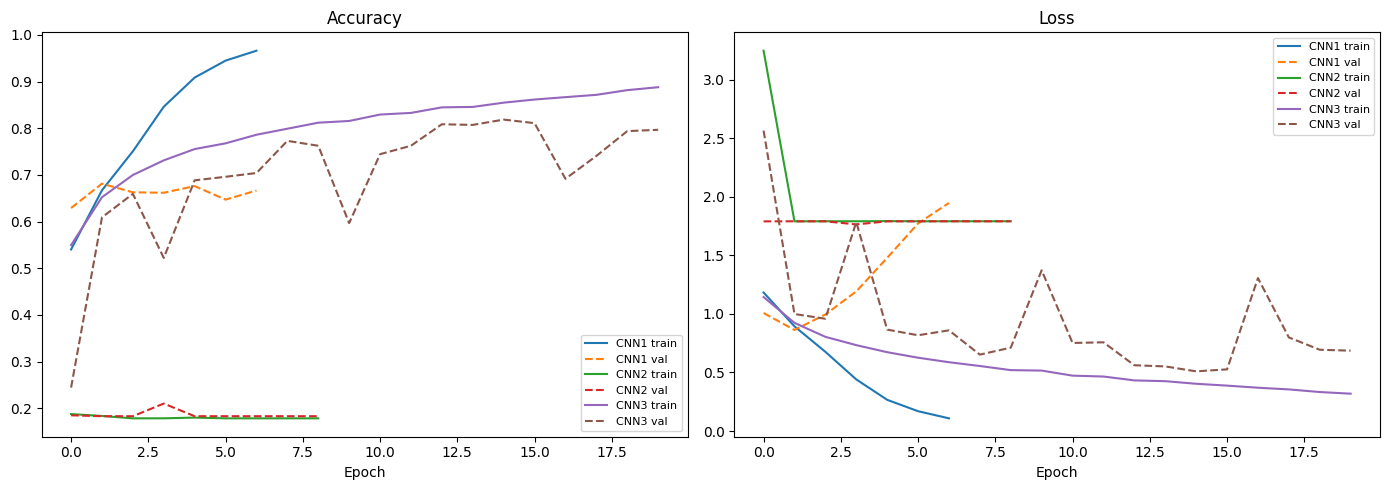

In [16]:
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for h, n in zip(histories, names):
        axes[0].plot(h.history['accuracy'], label=f'{n} train')
        axes[0].plot(h.history['val_accuracy'], '--', label=f'{n} val')
        axes[1].plot(h.history['loss'], label=f'{n} train')
        axes[1].plot(h.history['val_loss'], '--', label=f'{n} val')
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

plot_history([history_cnn1, history_cnn2, history_cnn3],
             ["CNN1", "CNN2", "CNN3"])

## Part 6 — Evaluate Every CNN Independently

Using the **same test set** for all three models (and later the ensemble) for a fair comparison.

In [17]:
# Reload the best checkpoint of each model
cnn1_best = tf.keras.models.load_model("models/cnn_baseline.keras")
cnn2_best = tf.keras.models.load_model("models/cnn_regularized.keras")
cnn3_best = tf.keras.models.load_model("models/cnn_deep.keras")

models_dict = {"CNN1_Baseline": cnn1_best, "CNN2_Regularized": cnn2_best, "CNN3_Deep": cnn3_best}

In [18]:
# Materialize the test set once (images + true labels) so it's reused identically everywhere
X_test, y_test_onehot = [], []
for imgs, lbls in test_ds:
    X_test.append(imgs.numpy())
    y_test_onehot.append(lbls.numpy())
X_test = np.concatenate(X_test, axis=0)
y_test_onehot = np.concatenate(y_test_onehot, axis=0)
y_test = np.argmax(y_test_onehot, axis=1)
print("Test set shape:", X_test.shape, "| labels:", y_test.shape)

Test set shape: (3000, 128, 128, 3) | labels: (3000,)


In [19]:
def evaluate_model(model, name, X, y_true):
    probs = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, average='macro', zero_division=0)
    rec = recall_score(y_true, preds, average='macro', zero_division=0)
    f1 = f1_score(y_true, preds, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, preds)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    return {"name": name, "probs": probs, "preds": preds, "accuracy": acc,
            "precision": prec, "recall": rec, "f1": f1, "confusion_matrix": cm}

results = {}
for name, m in models_dict.items():
    results[name] = evaluate_model(m, name, X_test, y_test)

--- CNN1_Baseline ---
Accuracy: 0.6583 | Precision: 0.6783 | Recall: 0.6653 | F1: 0.6573
--- CNN2_Regularized ---
Accuracy: 0.2050 | Precision: 0.1478 | Recall: 0.1935 | F1: 0.1009
--- CNN3_Deep ---
Accuracy: 0.8120 | Precision: 0.8200 | Recall: 0.8172 | F1: 0.8127


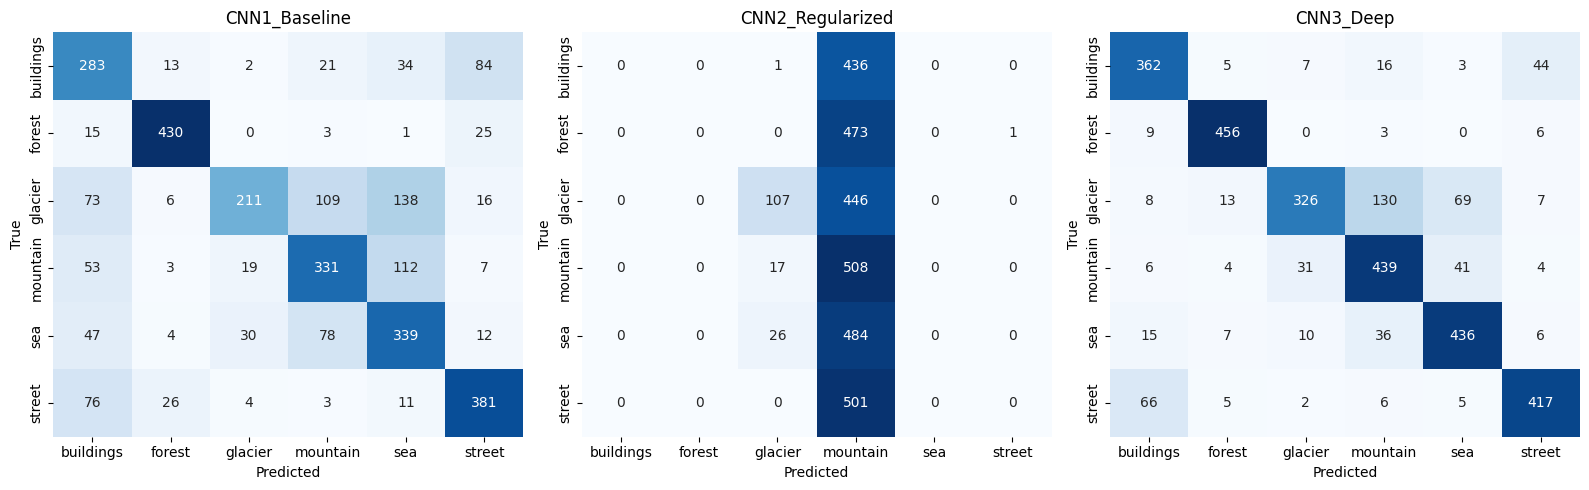

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r["confusion_matrix"], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

## Part 7 — Ensemble: Majority Voting & Soft Voting

In [21]:
def majority_voting(pred_list):
    stacked = np.stack(pred_list, axis=1)  # (N, num_models)
    final = []
    for row in stacked:
        vals, counts = np.unique(row, return_counts=True)
        final.append(vals[np.argmax(counts)])
    return np.array(final)

def soft_voting(prob_list, weights=None):
    # prob_list: list of (N, num_classes) softmax probability arrays
    if weights is None:
        weights = [1.0] * len(prob_list)
    weighted = np.zeros_like(prob_list[0])
    for p, w in zip(prob_list, weights):
        weighted += w * p
    weighted /= sum(weights)
    return np.argmax(weighted, axis=1), weighted

preds_list = [results[n]["preds"] for n in models_dict]
probs_list = [results[n]["probs"] for n in models_dict]

majority_preds = majority_voting(preds_list)
soft_preds, soft_probs = soft_voting(probs_list)  # equal weights = 1/3 each

In [22]:
def report(preds, name):
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro', zero_division=0)
    rec = recall_score(y_test, preds, average='macro', zero_division=0)
    f1 = f1_score(y_test, preds, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, preds)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    return {"name": name, "preds": preds, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "confusion_matrix": cm}

results["Ensemble_MajorityVoting"] = report(majority_preds, "Ensemble - Majority Voting")
results["Ensemble_SoftVoting"] = report(soft_preds, "Ensemble - Soft Voting")

--- Ensemble - Majority Voting ---
Accuracy: 0.7403 | Precision: 0.7767 | Recall: 0.7473 | F1: 0.7427
--- Ensemble - Soft Voting ---
Accuracy: 0.8200 | Precision: 0.8284 | Recall: 0.8249 | F1: 0.8196


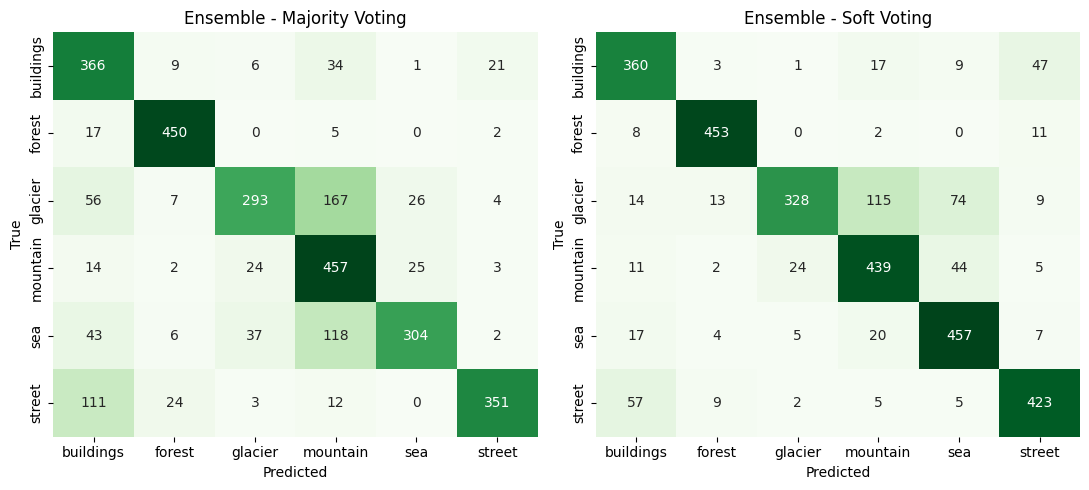

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, key in zip(axes, ["Ensemble_MajorityVoting", "Ensemble_SoftVoting"]):
    sns.heatmap(results[key]["confusion_matrix"], annot=True, fmt='d', cmap='Greens',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(results[key]["name"]); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

In [24]:
weights = [results[n]["accuracy"] for n in models_dict]
weighted_preds, weighted_probs = soft_voting(probs_list, weights=weights)
results["Ensemble_WeightedVoting"] = report(weighted_preds, "Ensemble - Weighted Voting")

--- Ensemble - Weighted Voting ---
Accuracy: 0.8240 | Precision: 0.8323 | Recall: 0.8293 | F1: 0.8242


## Part 8 — Production Benchmark: Latency, Throughput, Model Size, Parameters, Memory

In [25]:
import psutil

def count_params(model):
    return model.count_params()

def model_file_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2)

def benchmark_latency_throughput(model, X, n_warmup=5, n_runs=50):
    # Single-image latency
    sample = X[:1]
    for _ in range(n_warmup):
        model.predict(sample, verbose=0)
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        model.predict(sample, verbose=0)
        times.append((time.perf_counter() - t0) * 1000)  # ms
    latency_ms = float(np.mean(times))

    batch = X[:min(256, len(X))]
    t0 = time.perf_counter()
    model.predict(batch, batch_size=32, verbose=0)
    elapsed = time.perf_counter() - t0
    throughput = len(batch) / elapsed  

    return latency_ms, throughput

def estimate_memory_mb(model):
    param_bytes = model.count_params() * 4
    return param_bytes / (1024 ** 2)

def process_rss_mb():
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)

In [26]:
benchmark_rows = []

for name, m in models_dict.items():
    path = f"models/{ {'CNN1_Baseline':'cnn_baseline','CNN2_Regularized':'cnn_regularized','CNN3_Deep':'cnn_deep'}[name] }.keras"
    lat, thr = benchmark_latency_throughput(m, X_test)
    size_mb = model_file_size_mb(path)
    params = count_params(m)
    mem_mb = estimate_memory_mb(m)
    benchmark_rows.append({
        "Model": name, "Accuracy": results[name]["accuracy"], "F1": results[name]["f1"],
        "Latency (ms)": lat, "Throughput (img/s)": thr,
        "Model Size (MB)": size_mb, "Parameters": params, "Est. Memory (MB)": mem_mb,
    })

# Ensemble benchmark = sum of all three models loaded + sequential inference cost
ens_lat = sum(r["Latency (ms)"] for r in benchmark_rows)
ens_thr = 1.0 / sum(1.0 / r["Throughput (img/s)"] for r in benchmark_rows)  # bottlenecked by slowest stage in sequence
ens_size = sum(r["Model Size (MB)"] for r in benchmark_rows)
ens_params = sum(r["Parameters"] for r in benchmark_rows)
ens_mem = sum(r["Est. Memory (MB)"] for r in benchmark_rows)

for ens_name in ["Ensemble_MajorityVoting", "Ensemble_SoftVoting", "Ensemble_WeightedVoting"]:
    benchmark_rows.append({
        "Model": ens_name, "Accuracy": results[ens_name]["accuracy"], "F1": results[ens_name]["f1"],
        "Latency (ms)": ens_lat, "Throughput (img/s)": ens_thr,
        "Model Size (MB)": ens_size, "Parameters": ens_params, "Est. Memory (MB)": ens_mem,
    })

import pandas as pd
benchmark_df = pd.DataFrame(benchmark_rows).set_index("Model")
benchmark_df.round(3)

,Accuracy,F1,Latency (ms),Throughput (img/s),Model Size (MB),Parameters,Est. Memory (MB)
Model,,,,,,,
CNN1_Baseline,0.658,0.657,67.577,1086.655,84.643,7393094,28.202
CNN2_Regularized,0.205,0.101,68.337,1131.196,96.293,8409286,32.079
CNN3_Deep,0.812,0.813,67.327,1065.741,1.871,157606,0.601
Ensemble_MajorityVoting,0.740,0.743,203.241,364.619,182.807,15959986,60.883
Ensemble_SoftVoting,0.820,0.820,203.241,364.619,182.807,15959986,60.883
Ensemble_WeightedVoting,0.824,0.824,203.241,364.619,182.807,15959986,60.883


## Part 9 — Robustness Testing

Evaluating on modified versions of the test set: rotated, blurred, noisy, darker and brighter images. This simulates real-world capture conditions the model wasn't explicitly trained on.

In [27]:
import scipy.ndimage as ndi

def apply_rotation(X, angle=25):
    return np.stack([ndi.rotate(img, angle, reshape=False, mode='nearest') for img in X])

def apply_blur(X, sigma=1.5):
    return np.stack([ndi.gaussian_filter(img, sigma=(sigma, sigma, 0)) for img in X])

def apply_noise(X, std=0.08):
    noisy = X + np.random.normal(0, std, X.shape)
    return np.clip(noisy, 0.0, 1.0)

def apply_darker(X, factor=0.5):
    return np.clip(X * factor, 0.0, 1.0)

def apply_brighter(X, factor=1.5):
    return np.clip(X * factor, 0.0, 1.0)

# Use a subset for speed
N_ROBUST = min(300, len(X_test))
idx = np.random.RandomState(SEED).choice(len(X_test), N_ROBUST, replace=False)
X_sub, y_sub = X_test[idx], y_test[idx]

perturbations = {
    "Original": X_sub,
    "Rotated": apply_rotation(X_sub),
    "Blurred": apply_blur(X_sub),
    "Noisy": apply_noise(X_sub),
    "Darker": apply_darker(X_sub),
    "Brighter": apply_brighter(X_sub),
}

In [28]:
def predict_probs(model, X):
    return model.predict(X, batch_size=32, verbose=0)

robust_rows = []
member_probs_by_perturbation = {}

for pert_name, X_pert in perturbations.items():
    prob_list = []
    for name, m in models_dict.items():
        probs = predict_probs(m, X_pert)
        prob_list.append(probs)
        preds = np.argmax(probs, axis=1)
        robust_rows.append({"Perturbation": pert_name, "Model": name,
                             "Accuracy": accuracy_score(y_sub, preds)})
    member_probs_by_perturbation[pert_name] = prob_list

    soft_p, soft_prob = soft_voting(prob_list)
    robust_rows.append({"Perturbation": pert_name, "Model": "Ensemble_SoftVoting",
                         "Accuracy": accuracy_score(y_sub, soft_p)})
    maj_p = majority_voting([np.argmax(p, axis=1) for p in prob_list])
    robust_rows.append({"Perturbation": pert_name, "Model": "Ensemble_MajorityVoting",
                         "Accuracy": accuracy_score(y_sub, maj_p)})

robust_df = pd.DataFrame(robust_rows)
robust_pivot = robust_df.pivot(index="Model", columns="Perturbation", values="Accuracy")
robust_pivot = robust_pivot[["Original", "Rotated", "Blurred", "Noisy", "Darker", "Brighter"]]
robust_pivot.round(3)

Perturbation,Original,Rotated,Blurred,Noisy,Darker,Brighter
Model,,,,,,
CNN1_Baseline,0.620,0.637,0.480,0.560,0.567,0.643
CNN2_Regularized,0.193,0.190,0.217,0.167,0.170,0.197
CNN3_Deep,0.823,0.807,0.483,0.423,0.760,0.773
Ensemble_MajorityVoting,0.710,0.717,0.483,0.493,0.633,0.693
Ensemble_SoftVoting,0.807,0.803,0.507,0.520,0.777,0.787


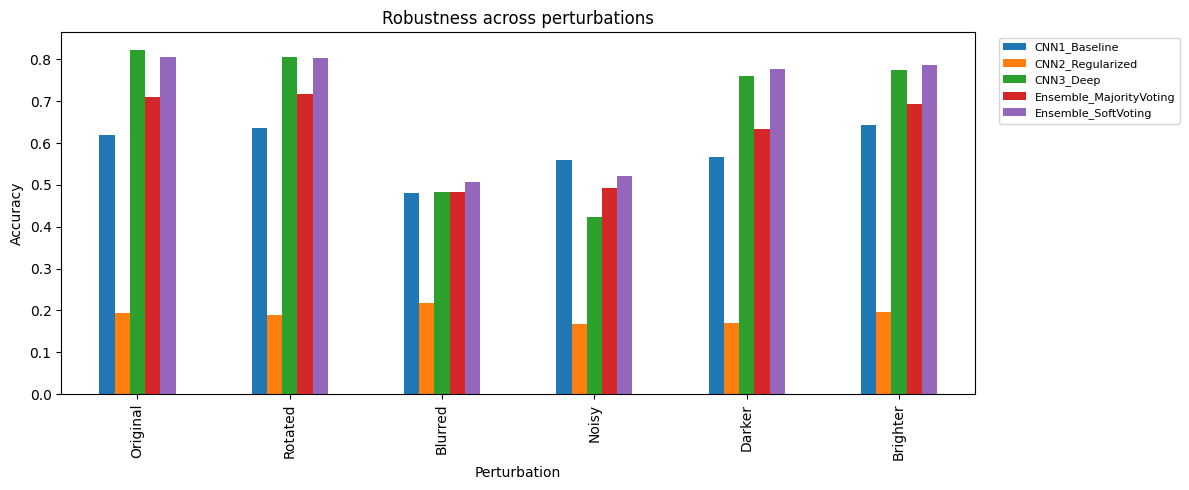

In [29]:
robust_pivot.T.plot(kind='bar', figsize=(12, 5))
plt.ylabel("Accuracy"); plt.title("Robustness across perturbations")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## Part 10 — Model Disagreement Analysis

How often do the three CNNs disagree with each other, and how often does the ensemble fix a mistake that an individual model made?

In [30]:
preds_matrix = np.stack(preds_list, axis=1)  # (N, 3) on the full test set
all_agree = np.all(preds_matrix == preds_matrix[:, [0]], axis=1)
print(f"All 3 CNNs agree on {all_agree.mean()*100:.1f}% of test images")
print(f"CNNs disagree on {(~all_agree).mean()*100:.1f}% of test images")

# Cases where the individually-best CNN was wrong but the soft-voting ensemble was right
best_model_name = max(models_dict, key=lambda n: results[n]["accuracy"])
best_preds = results[best_model_name]["preds"]
soft_ens_preds = results["Ensemble_SoftVoting"]["preds"]

fixed_by_ensemble = np.sum((best_preds != y_test) & (soft_ens_preds == y_test))
broken_by_ensemble = np.sum((best_preds == y_test) & (soft_ens_preds != y_test))
print(f"\nBest individual model: {best_model_name} (acc={results[best_model_name]['accuracy']:.4f})")
print(f"Cases the ensemble FIXED (best CNN wrong, ensemble right): {fixed_by_ensemble}")
print(f"Cases the ensemble BROKE (best CNN right, ensemble wrong): {broken_by_ensemble}")
print(f"Net effect: {fixed_by_ensemble - broken_by_ensemble:+d} images")

All 3 CNNs agree on 14.9% of test images
CNNs disagree on 85.1% of test images

Best individual model: CNN3_Deep (acc=0.8120)
Cases the ensemble FIXED (best CNN wrong, ensemble right): 101
Cases the ensemble BROKE (best CNN right, ensemble wrong): 77
Net effect: +24 images


## Part 11 — Final Benchmark Table & Accuracy-vs-Cost Trade-off

In [31]:
final_table = benchmark_df.copy()
final_table["Precision"] = [results[n]["precision"] for n in final_table.index]
final_table["Recall"] = [results[n]["recall"] for n in final_table.index]
final_table = final_table[["Accuracy", "Precision", "Recall", "F1", "Latency (ms)",
                            "Throughput (img/s)", "Model Size (MB)", "Parameters", "Est. Memory (MB)"]]
final_table.round(3)

,Accuracy,Precision,Recall,F1,Latency (ms),Throughput (img/s),Model Size (MB),Parameters,Est. Memory (MB)
Model,,,,,,,,,
CNN1_Baseline,0.658,0.678,0.665,0.657,67.577,1086.655,84.643,7393094,28.202
CNN2_Regularized,0.205,0.148,0.194,0.101,68.337,1131.196,96.293,8409286,32.079
CNN3_Deep,0.812,0.820,0.817,0.813,67.327,1065.741,1.871,157606,0.601
Ensemble_MajorityVoting,0.740,0.777,0.747,0.743,203.241,364.619,182.807,15959986,60.883
Ensemble_SoftVoting,0.820,0.828,0.825,0.820,203.241,364.619,182.807,15959986,60.883
Ensemble_WeightedVoting,0.824,0.832,0.829,0.824,203.241,364.619,182.807,15959986,60.883


In [32]:
best_individual = final_table.loc[["CNN1_Baseline", "CNN2_Regularized", "CNN3_Deep"], "Accuracy"].idxmax()
best_ensemble = final_table.loc[["Ensemble_MajorityVoting", "Ensemble_SoftVoting", "Ensemble_WeightedVoting"], "Accuracy"].idxmax()

acc_gain = final_table.loc[best_ensemble, "Accuracy"] - final_table.loc[best_individual, "Accuracy"]
lat_increase = final_table.loc[best_ensemble, "Latency (ms)"] - final_table.loc[best_individual, "Latency (ms)"]
thr_drop = final_table.loc[best_individual, "Throughput (img/s)"] - final_table.loc[best_ensemble, "Throughput (img/s)"]

print(f"Best individual CNN : {best_individual}  (acc={final_table.loc[best_individual,'Accuracy']:.4f}, "
      f"latency={final_table.loc[best_individual,'Latency (ms)']:.1f} ms)")
print(f"Best ensemble        : {best_ensemble}  (acc={final_table.loc[best_ensemble,'Accuracy']:.4f}, "
      f"latency={final_table.loc[best_ensemble,'Latency (ms)']:.1f} ms)")
print(f"\nAccuracy gain from ensembling : {acc_gain*100:+.2f} percentage points")
print(f"Latency increase              : {lat_increase:+.1f} ms")
print(f"Throughput drop                : {thr_drop:+.1f} img/s")

Best individual CNN : CNN3_Deep  (acc=0.8120, latency=67.3 ms)
Best ensemble        : Ensemble_WeightedVoting  (acc=0.8240, latency=203.2 ms)

Accuracy gain from ensembling : +1.20 percentage points
Latency increase              : +135.9 ms
Throughput drop                : +701.1 img/s
